In [ ]:
'''This code calculates the cumulative fluence I(x,y) on a "unit cell"
as a function of scan parameters by summing all the Gaussian beams
For details about the calculation, see the pdf in this directory
Written by Calvin Firth (UMN)
Last updated Fall 2025'''

In [1]:
#Scan parameters
P = 20 # Power
gw =108 # Groove width (um)
ls = 9 # Line spacing (um)
Px = 217 # Pitch in the x direction
Py = 217 # Pitch in the y direction
SS = 300000 # Scan speed (um/s)
RR = 100000 # Rep rate (Hz)
n=10 # Number of layers
a = 23/2 # 1/e^2 beam radius

In [3]:
import sys
sys.path.append("..")
import matplotlib.pyplot as plt
import numpy as np
from plotting import errbar
from mpl_point_clicker import clicker
from mpl_interactions import zoom_factory, panhandler
from image_helper import get_pitch, open_image

def fluence_func(x,y,gw,ls,Px,Py,SS,RR,n,I_0,a):
    return n*I_0*(sum([np.exp(-2*(((x-(SS/RR)*i)**2 + (y-(j*ls + (Py-gw)/2))**2)/(a**2))) for i in range(int(-(0.05*Px)/(SS/RR)),int((1.05*Px)/(SS/RR))+1) for j in range(int(gw/ls)+1)]) + sum(np.exp(-2*(((x-(i*ls + (Px-gw)/2))**2 + (y-j*(SS/RR))**2)/a**2)) for i in range(int(gw/ls) + 1) for j in range(int(-(0.05*Py)/(SS/RR)),int((1.05*Py)/(SS/RR))+1)) )

(array([  0.,  25.,  50.,  75., 100., 125., 150., 175., 200., 225.]),
 [Text(0, 0.0, '0'),
  Text(0, 25.0, '25'),
  Text(0, 50.0, '50'),
  Text(0, 75.0, '75'),
  Text(0, 100.0, '100'),
  Text(0, 125.0, '125'),
  Text(0, 150.0, '150'),
  Text(0, 175.0, '175'),
  Text(0, 200.0, '200'),
  Text(0, 225.0, '225')])

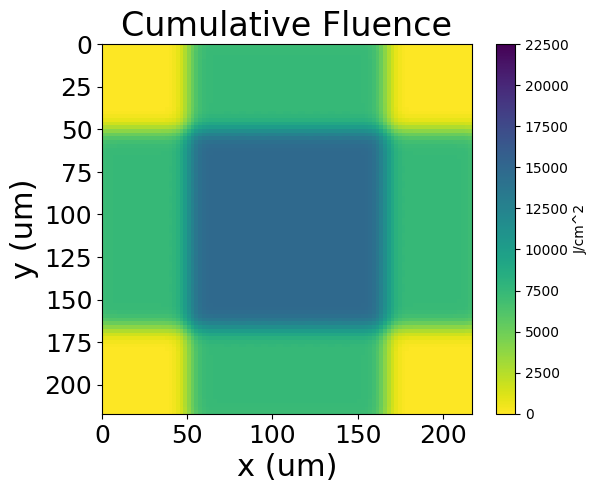

In [6]:
x = np.linspace(0,Px,res)
y = np.linspace(0,Py,res)

x,y = np.meshgrid(x,y)

I_0 = 2*(P/RR)/(np.pi*(a*10**-4)**2)
inv_f = (fluence_func(x,y,gw,ls,Px,Py,SS,RR,n,I_0,a))

plt.imshow(inv_f, extent = (0,Px,Py,0),vmin = 0,vmax=22500,cmap="viridis_r")
plt.colorbar(label = "J/cm^2")
plt.title("Cumulative Fluence", fontsize=24)
plt.xlabel("x (um)", fontsize = 22)
plt.ylabel("y (um)", fontsize =22)
plt.xticks(fontsize = 18)
plt.yticks(fontsize = 18)